**Intelligent Vision Systems · Lab 5 · Self-Driving Car Vision: Finding Lane Lines**  
Companion to **Lecture 5 (Part II) — Computer Vision for Self-Driving Cars**  
Dr. Muhammad Kazim · Department of Intelligent Systems, University of Lahore

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kazimbalti/intelligent-vision-systems/blob/main/LAB/Lab_5/03-canny-edges.ipynb) &nbsp; [Lecture 5 Part II slides](https://kazimbalti.github.io/intelligent-vision-systems/lectures/05_SDC_Lane_Finding.html#/canny-edge-detection) &nbsp; [All Lab 5 notebooks](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-lane-lines)

# Lab 5C · Canny Edge Detection

_Lecture 5 Part II, Section 4: Canny Edge Detection._

Lane lines are not always white or yellow, and lighting changes their colour. **Edges** — places where brightness changes
quickly — are a much more general cue. John F. Canny's 1986 detector is still the standard way to find them.

In [1]:
# Setup (only needed on Google Colab or a fresh environment).
# Uncomment the next line to install the packages this notebook uses:
# !pip install -q opencv-python numpy matplotlib

import os, urllib.request

# Fetch the lab images if they are not next to the notebook.
RAW = "https://raw.githubusercontent.com/Kazimbalti/intelligent-vision-systems/main/LAB/Lab_5"
for f in ['lab5_checks.py', 'exit-ramp.jpg']:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/{f}", f)
print("data ready")

data ready


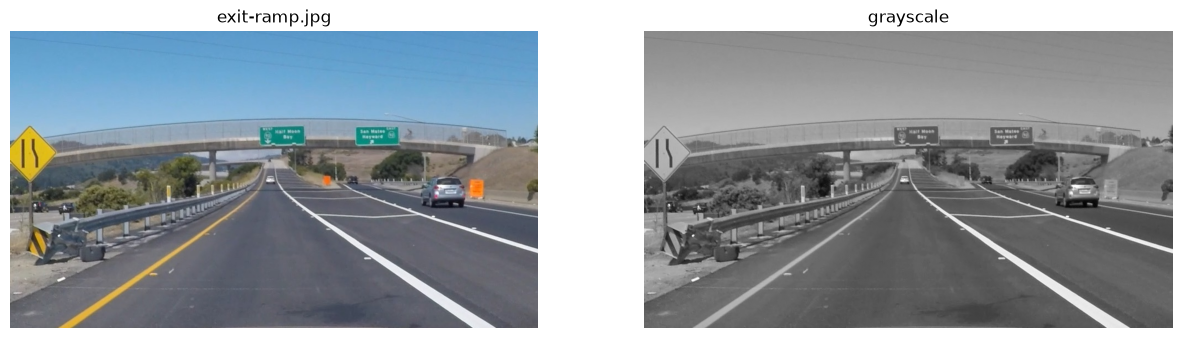

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import lab5_checks as C   # auto-checks for this lab

image = mpimg.imread("exit-ramp.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)          # one 8-bit number per pixel (0-255)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].imshow(image); ax[0].set_title("exit-ramp.jpg"); ax[1].imshow(gray, cmap="gray"); ax[1].set_title("grayscale")
for a in ax: a.axis("off")
plt.show()

## 1. An image is a function; edges are where its derivative is large

Treat the image as `f(x, y) = pixel value`. Plot one **row** across the road: the lane lines show up as sharp jumps.

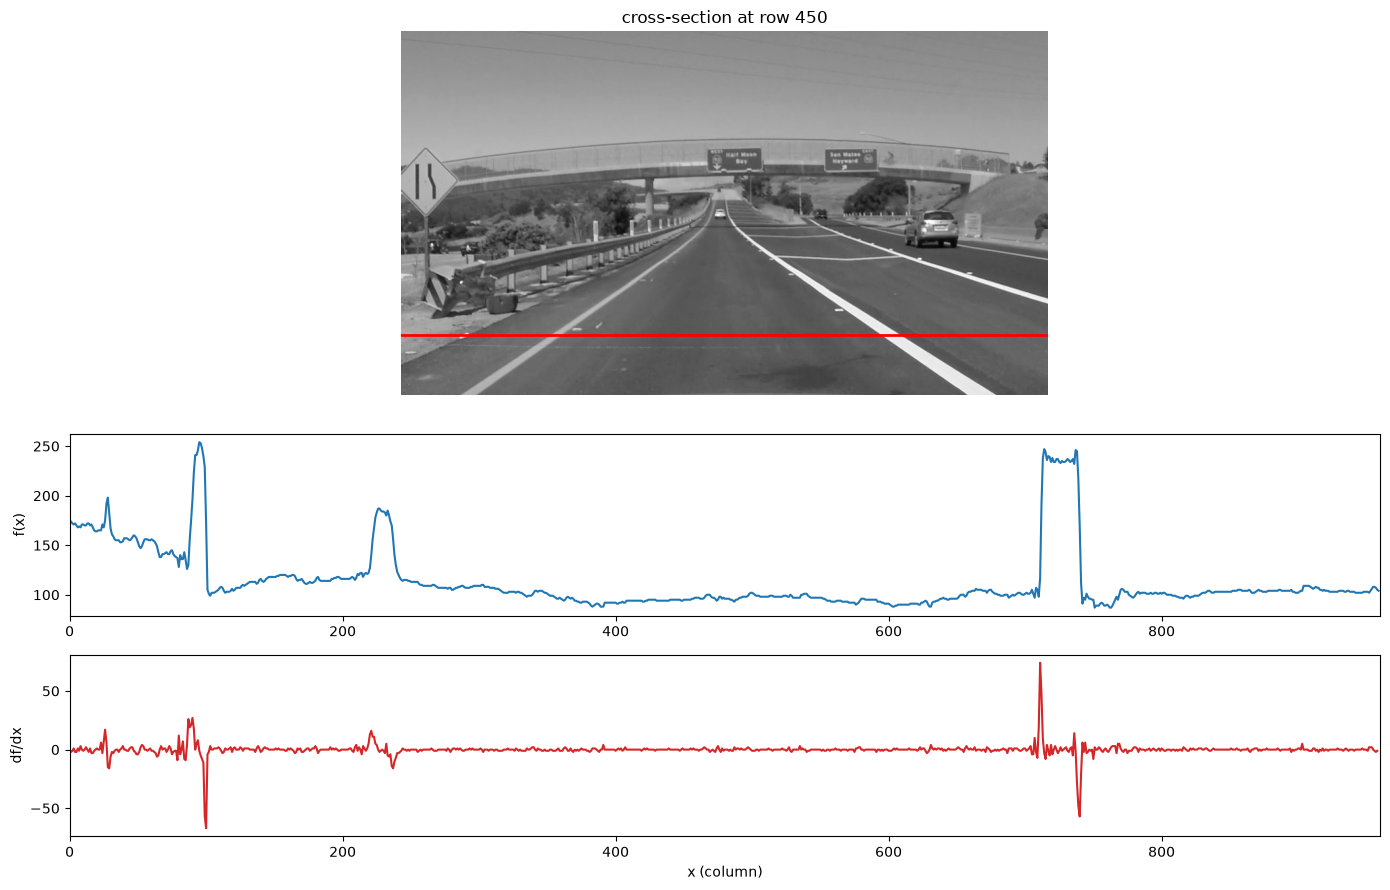

In [3]:
row = 450
profile = gray[row].astype(float)
deriv = np.diff(profile)                                 # df/dx ~ f(x+1) - f(x)

fig, ax = plt.subplots(3, 1, figsize=(14, 9), gridspec_kw=dict(height_ratios=[2, 1, 1]))
ax[0].imshow(gray, cmap="gray"); ax[0].axhline(row, color="red", lw=2); ax[0].set_title(f"cross-section at row {row}"); ax[0].axis("off")
ax[1].plot(profile); ax[1].set_ylabel("f(x)"); ax[1].set_xlim(0, len(profile))
ax[2].plot(deriv, color="C3"); ax[2].set_ylabel("df/dx"); ax[2].set_xlim(0, len(profile)); ax[2].set_xlabel("x (column)")
plt.tight_layout(); plt.show()

## 2. The gradient: derivative in x **and** y

Sobel filters estimate `∂f/∂x` and `∂f/∂y`. The **magnitude** `√(Gx² + Gy²)` measures edge strength; the **direction**
`atan2(Gy, Gx)` is perpendicular to the edge. Notice how *thick* the gradient edges are — Canny will thin them.

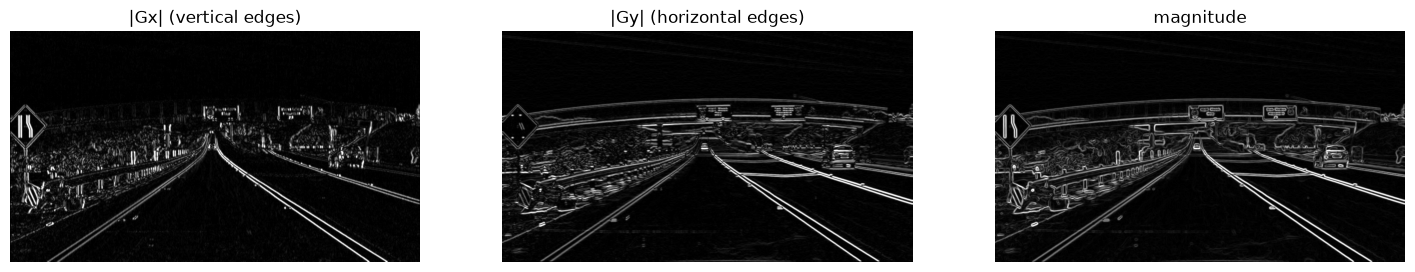

In [4]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)
gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
mag = np.hypot(gx, gy)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for a, im, t in zip(ax, [np.abs(gx), np.abs(gy), mag], ["|Gx| (vertical edges)", "|Gy| (horizontal edges)", "magnitude"]):
    a.imshow(im, cmap="gray", vmax=np.percentile(im, 99.5)); a.set_title(t); a.axis("off")
plt.show()

## 3. `cv2.Canny`: smoothing → gradient → thinning → hysteresis

```python
edges = cv2.Canny(gray, low_threshold, high_threshold)
```

* pixels with gradient **above `high_threshold`** are *strong* edges;
* pixels **below `low_threshold`** are rejected;
* pixels **in between** are kept only if they are **connected to a strong edge** (hysteresis).

Because the image is 8-bit (0–255), gradients are in the tens to hundreds, so thresholds should be too. Canny recommended a
**low:high ratio of 1:2 or 1:3**.

> **Correction to the original lesson:** `cv2.Canny` does **not** blur the image internally — it computes Sobel derivatives
> directly (`apertureSize=3`). That is exactly why we apply `cv2.GaussianBlur` first. `kernel_size` must be **odd**;
> bigger kernels smooth more.

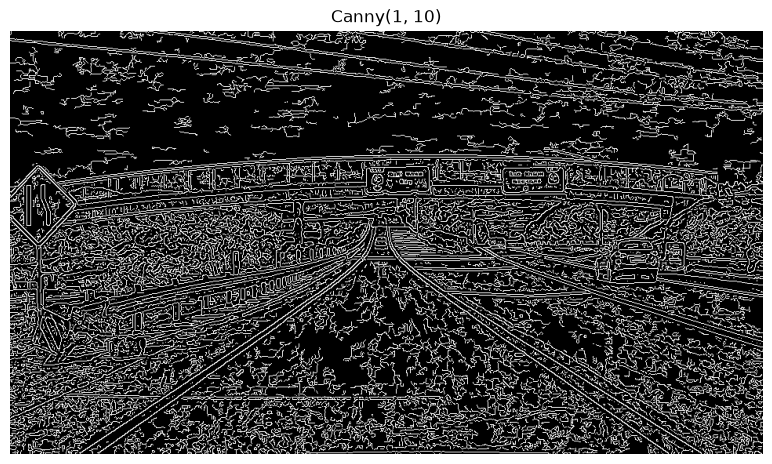

In [5]:
# Define a kernel size for Gaussian smoothing / blurring
kernel_size = 3
blur_gray = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)

# Define parameters for Canny and run it
# NOTE: these values are far too low - change them in the quiz below!
low_threshold = 1
high_threshold = 10
edges = cv2.Canny(blur_gray, low_threshold, high_threshold)

plt.figure(figsize=(10, 5.5)); plt.imshow(edges, cmap="Greys_r"); plt.title(f"Canny({low_threshold}, {high_threshold})"); plt.axis("off"); plt.show()

## 4. Quiz — tune blur and thresholds

Find values that keep the lane lines but drop most of the trees, signs and road texture.

<details><summary><b>Show the answer</b> (try first!)</summary>

`kernel_size = 5`, `low_threshold = 50`, `high_threshold = 150` (ratio 1:3) extracts the lane lines nicely while
minimising the other edges.
</details>

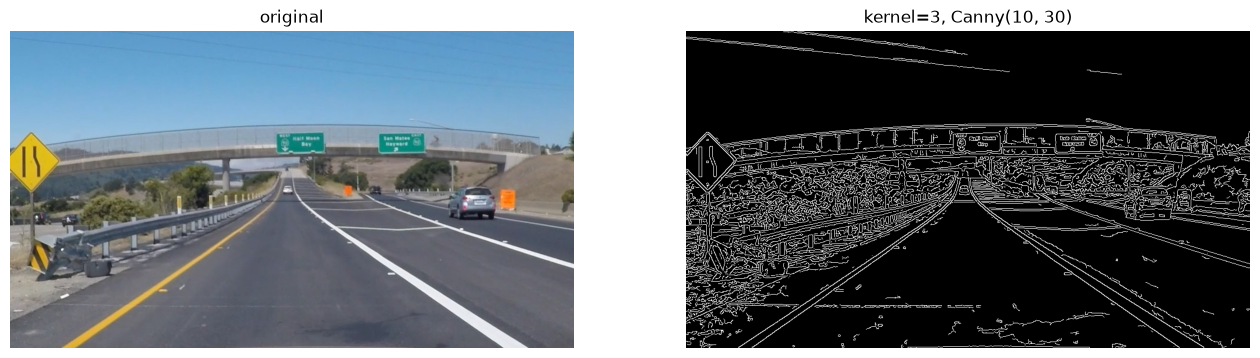

edge pixels: 46555


In [6]:
# MODIFY THESE
kernel_size = 3
low_threshold = 10
high_threshold = 30

blur_gray = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)
edges = cv2.Canny(blur_gray, low_threshold, high_threshold)
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
ax[0].imshow(image); ax[0].set_title("original")
ax[1].imshow(edges, cmap="Greys_r"); ax[1].set_title(f"kernel={kernel_size}, Canny({low_threshold}, {high_threshold})")
for a in ax: a.axis("off")
plt.show()
print("edge pixels:", int((edges > 0).sum()))

### ✅ Auto-check
Run the cell below after every change. It prints ✅ when your result is good, or a 💡 hint — never the answer.

In [7]:
C.check_canny(edges)

   lane lines covered: left 100%, right 100% · edge pixels: 46,555
💡 Lots of clutter (trees, texture). Raise the thresholds and/or use a bigger odd blur kernel.


False

## 5. Seeing the effect of each parameter

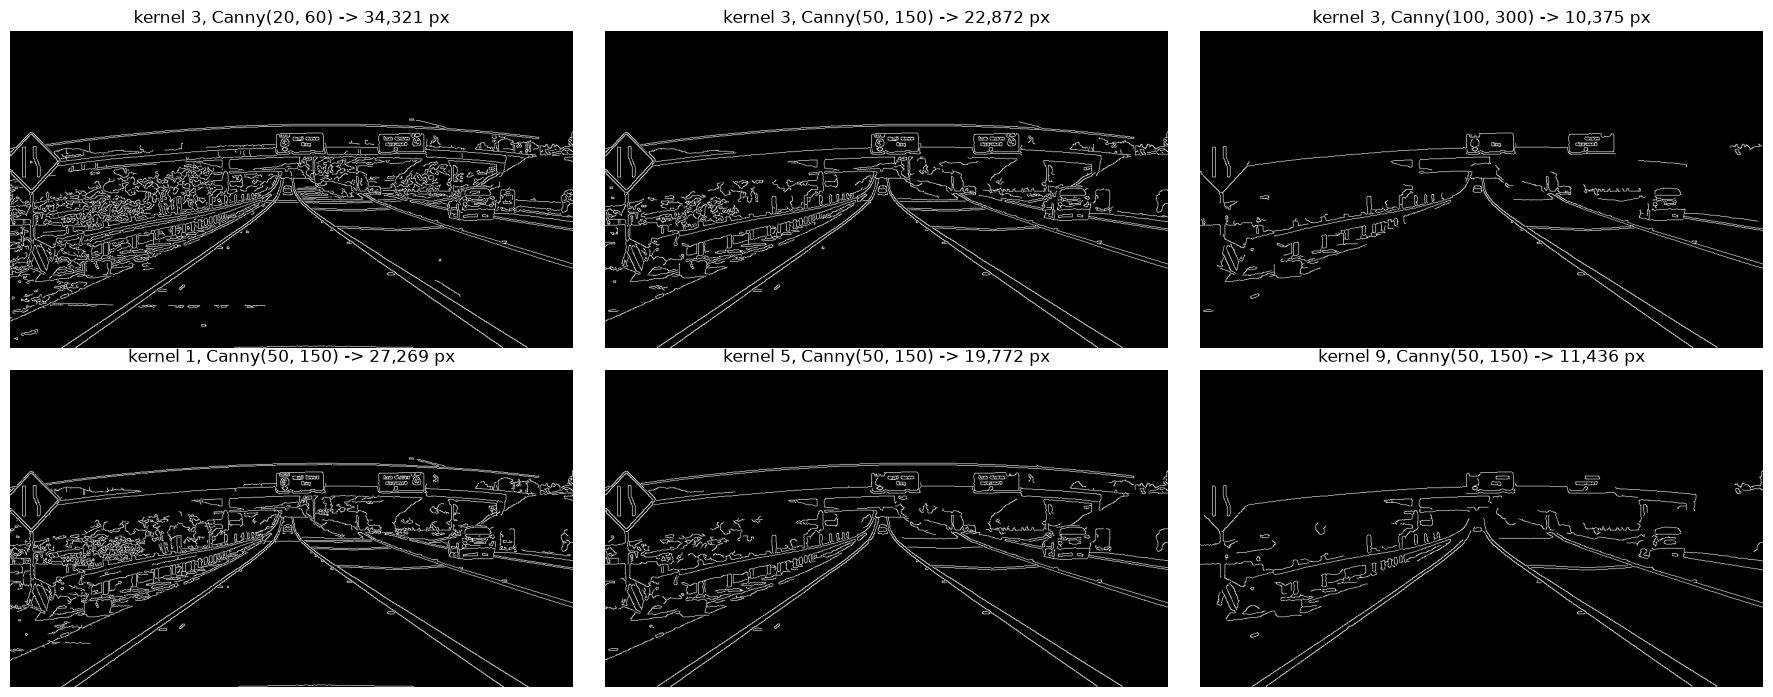

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(18, 7))
for a, (k, lo, hi) in zip(ax.ravel(), [(3, 20, 60), (3, 50, 150), (3, 100, 300),
                                         (1, 50, 150), (5, 50, 150), (9, 50, 150)]):
    e = cv2.Canny(cv2.GaussianBlur(gray, (k, k), 0), lo, hi)
    a.imshow(e, cmap="Greys_r"); a.set_title(f"kernel {k}, Canny({lo}, {hi}) -> {(e > 0).sum():,} px"); a.axis("off")
plt.tight_layout(); plt.show()

## Your turn — Lab 5C tasks

1. Report your chosen `kernel_size`, `low_threshold`, `high_threshold` and the number of edge pixels. Justify the choice in two sentences.
2. Keep `high_threshold = 150` and vary the ratio (1:1, 1:2, 1:3, 1:5). What does hysteresis add compared with a single threshold?
3. Implement a **single-threshold** edge map from the Sobel magnitude (`mag > T`) and compare it visually with Canny.
   Which two Canny steps explain the difference? (Hint: thin vs thick, connected vs broken.)

**Deliverable:** keep this notebook with your code, outputs and a short written answer to each task.